In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv(r"C:\Users\sanka\Desktop\FUTURE_ML_01\Sample - Superstore.csv", encoding='latin-1')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7980,7981,CA-2014-103800,2014-01-03,1/7/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
739,740,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
740,741,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
741,742,CA-2014-112326,2014-01-04,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
1759,1760,CA-2014-141817,2014-01-05,1/12/2014,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
# Remove missing values
df = df.dropna(subset=['Sales'])

In [5]:
# Aggregate sales by date
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

In [6]:
#feature engineering 
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Year'] = daily_sales['Order Date'].dt.year


In [7]:
#train and test the data 
train = daily_sales[daily_sales['Order Date'] < '2017-01-01']
test = daily_sales[daily_sales['Order Date'] >= '2017-01-01']

In [8]:
#by taking x as input variables and y as target sales
X_train = train[['Day', 'Month', 'Year']]
y_train = train['Sales']

X_test = test[['Day', 'Month', 'Year']]
y_test = test['Sales']

In [9]:
#using LR model 
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
#for prediction sales 
#.loc is used to avoid warning generated by pandas 
#":" use for all rows

test = test.copy()
test.loc[:, 'Predicted Sales'] = model.predict(X_test)


In [11]:
#cal mae and rmse for avrage prediction errors and penelizes larger errors 
mae = mean_absolute_error(y_test, test['Predicted Sales'])
rmse = np.sqrt(mean_squared_error(y_test, test['Predicted Sales']))


In [12]:
print("MAE:", mae)
print("RMSE:", rmse)


MAE: 1610.8254428881098
RMSE: 2333.618906429431


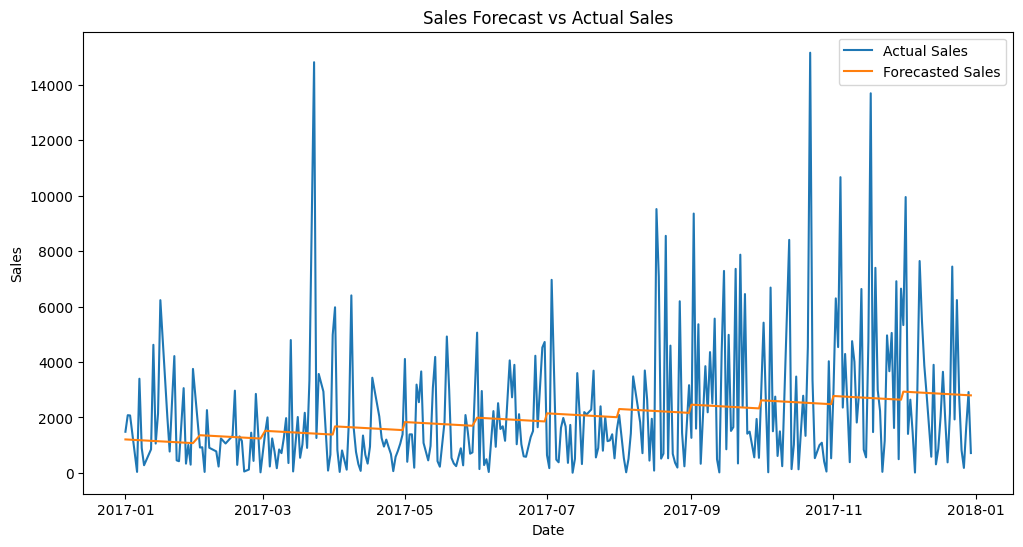

In [13]:
plt.figure(figsize=(12,6))
plt.plot(test['Order Date'], y_test, label='Actual Sales')
plt.plot(test['Order Date'], test['Predicted Sales'], label='Forecasted Sales')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecast vs Actual Sales")
plt.legend()
plt.show()


In [14]:
future_dates = pd.date_range(start=daily_sales['Order Date'].max(), periods=30)
future_df = pd.DataFrame({
    'Day': future_dates.day,
    'Month': future_dates.month,
    'Year': future_dates.year
})

In [15]:
future_sales = model.predict(future_df)

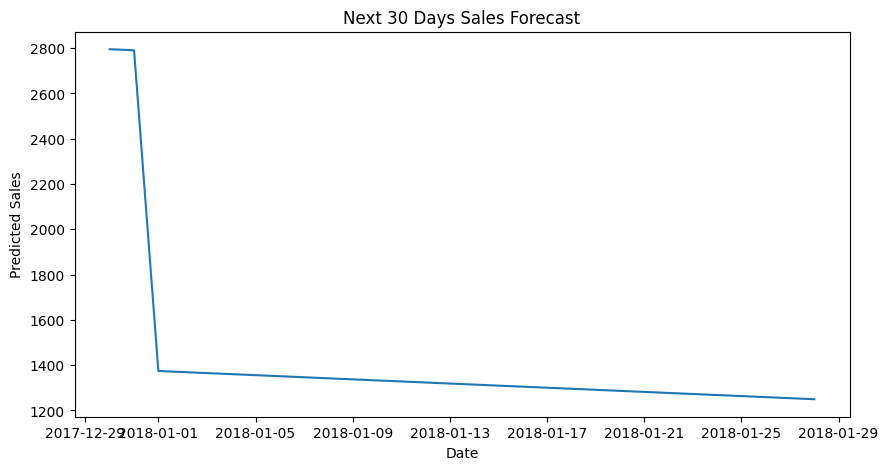

In [16]:
plt.figure(figsize=(10,5))
plt.plot(future_dates, future_sales)
plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.show()


In [ ]:
import gradio as gr


def forecast_sales(start_date, days):
    if start_date is None or str(start_date).strip() == "":
        start = daily_sales["Order Date"].max() + pd.Timedelta(days=1)
    else:
        start = pd.to_datetime(start_date, errors="coerce")
        if pd.isna(start):
            return pd.DataFrame(columns=["Date", "Predicted Sales"]), None

    future_dates = pd.date_range(start=start, periods=int(days))
    future_df = pd.DataFrame({
        "Day": future_dates.day,
        "Month": future_dates.month,
        "Year": future_dates.year
    })
    #important line 
    preds = model.predict(future_df)

    result = pd.DataFrame({
        "Date": future_dates,
        "Predicted Sales": preds
    })

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(result["Date"], result["Predicted Sales"], color="#4B5563")
    ax.set_title("Sales Forecast")
    ax.set_xlabel("Date")
    ax.set_ylabel("Predicted Sales")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    return result, fig


theme = gr.themes.Soft(
    primary_hue="gray",
    secondary_hue="gray",
    neutral_hue="gray"
)

with gr.Blocks(theme=theme) as demo:
    gr.Markdown("## Sales Forecast UI")
    gr.Markdown("Enter a start date (YYYY-MM-DD) and forecast window to predict future sales.")

    with gr.Row():
        start_date = gr.Textbox(
            label="Start date (YYYY-MM-DD)",
            placeholder="e.g., 2018-01-01",
            value=""
        )
        days = gr.Slider(1, 365, value=30, step=1, label="Forecast days")

    predict_btn = gr.Button("Predict")
    output_table = gr.Dataframe(label="Predictions", interactive=False)
    output_plot = gr.Plot(label="Forecast plot")

    predict_btn.click(
        forecast_sales,
        inputs=[start_date, days],
        outputs=[output_table, output_plot]
    )

demo.launch()

Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


c:\Users\sanka\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\analytics.py:106: UserWarning: IMPORTANT: You are using gradio version 4.44.0, however version 4.44.1 is available, please upgrade. 
--------
  warnings.warn(
